### Configuration

In [47]:
import numpy as np
import os
import pickle
import pandas as pd
import json
from tqdm import tqdm
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics
from methyldl.deconvolution.uxm import load_atlas, uxm_deconvolution, rearange_uxm_deconvolution_results
from edautils import plot_deconvolution_results
uxm_features_path = "/home/luna.kuleuven.be/u0169940/Repos/methyldl/Tutorials/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution"

In [4]:
ios_files = os.listdir(uxm_features_path)

In [25]:
with open("../App/labels_dict.json", "rb") as f:
    labels_dict = json.load(f) 
labels_dict = {int(key):value for (key,value) in labels_dict.items()}
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [21]:
atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location, ignore=["Megakaryocytes"])
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

### Deconvolution

In [39]:
sf[["name", "direction", "pseudo_bulk_sample"]]

,name,direction,pseudo_bulk_sample
0,chr10:103374221-103374687,U,0.000000
1,chr10:112492743-112492961,U,0.017450
2,chr10:113151854-113151920,U,0.089494
3,chr10:124601275-124601435,U,0.271028
4,chr10:124808171-124808466,U,0.000000
...,...,...,...
822,chr9:3689072-3689653,U,0.100559
823,chr9:39419458-39419933,U,0.000000
824,chr9:76623419-76623545,U,0.055096
825,chr9:81639317-81639676,U,0.045788


In [40]:
uxm_results = []
target_proportions = []
for file in tqdm(ios_files):
    with open(os.path.join(uxm_features_path, file), "rb") as f:
        res = pickle.load(f)
        for j in range(len(res)):
            # test split only
            props = res[j][0]
            sf = res[j][2][2][0]
            counts = res[j][2][2][1]
            uxm_proportions = uxm_deconvolution(
                atlas, ref_cells, sf, counts, sample_names=['pseudo_bulk_sample']
            )[0]
            uxm_deconv_alligned = rearange_uxm_deconvolution_results(
                labels_dict_reversed, uxm_proportions, ref_cells
            )
            uxm_results.append(uxm_deconv_alligned)
            target_proportions.append(props)

100%|██████████| 100/100 [15:41<00:00,  9.42s/it]


In [44]:
target_proportions = np.array(target_proportions)
uxm_results = np.array(uxm_results)

In [45]:
metrics = compute_deconvolution_metrics(uxm_results, target_proportions)

In [46]:
metrics

{'mae': 0.00556341647797364,
 'mse': 0.00029389506195860797,
 'kl': 0.1456824175048089,
 'max_error': 0.5138003510308036,
 'cosine_sim': 0.9850402915172394,
 'loa_lower': -0.03360100533487703,
 'loa_upper': 0.03360100533487703,
 'loa_width': 0.06720201066975406,
 'worst_class_idx': 11,
 'worst_class_name': 11,
 'worst_class_loa_lower': -0.06871436413236422,
 'worst_class_loa_upper': 0.09568783893939918,
 'worst_class_loa_width': 0.1644022030717634,
 'per_class_loa': {'bias': array([-5.57171434e-03, -1.22598507e-03, -2.84051379e-03, -5.60452641e-04,
          1.81379967e-03,  1.00706120e-02,  5.62872911e-04,  1.15965599e-02,
          1.61606610e-03, -1.94241041e-03, -1.62439371e-03,  1.34867374e-02,
         -2.55973485e-03, -1.81018132e-03,  1.98326374e-03, -1.42058249e-04,
          5.76037155e-04, -1.16102614e-03, -5.87143649e-04, -4.18090629e-04,
         -1.34098649e-03, -4.76704180e-03, -2.54606614e-03, -7.22545623e-05,
         -1.07739222e-03,  4.32622357e-04, -2.31801830e-03, 

(<Figure size 2000x1000 with 2 Axes>,
 {'celltype_metrics': {'overall_r2': 0.964509234709998,
   'per_celltype_r2': {'Adipocytes': 0.9398842793678348,
    'Bladder-Ep': 0.9778725280500754,
    'Blood-B': 0.9549224619529223,
    'Blood-Granul': 0.9932516621938583,
    'Blood-Mono+Macro': 0.98737888971058,
    'Blood-NK': 0.9264884410192042,
    'Blood-T': 0.9839732978543244,
    'Bone-Osteob': 0.9073371438484286,
    'Breast-Basal-Ep': 0.9929645557992688,
    'Breast-Luminal-Ep': 0.9846571997813853,
    'Colon-Ep': 0.9911292056618393,
    'Colon-Fibro': 0.7670155122567163,
    'Dermal-Fibro': 0.8361801030966326,
    'Endothel': 0.9382926329322366,
    'Epid-Kerat': 0.9715090724723642,
    'Eryth-prog': 0.9718408637608529,
    'Fallopian-Ep': 0.9676710778669739,
    'Gallbladder': 0.9855704020864019,
    'Gastric-Ep': 0.9911490350473007,
    'Head-Neck-Ep': 0.9916102409578869,
    'Heart-Cardio': 0.987676840290978,
    'Heart-Fibro': 0.9490141774710655,
    'Kidney-Ep': 0.978951557548360

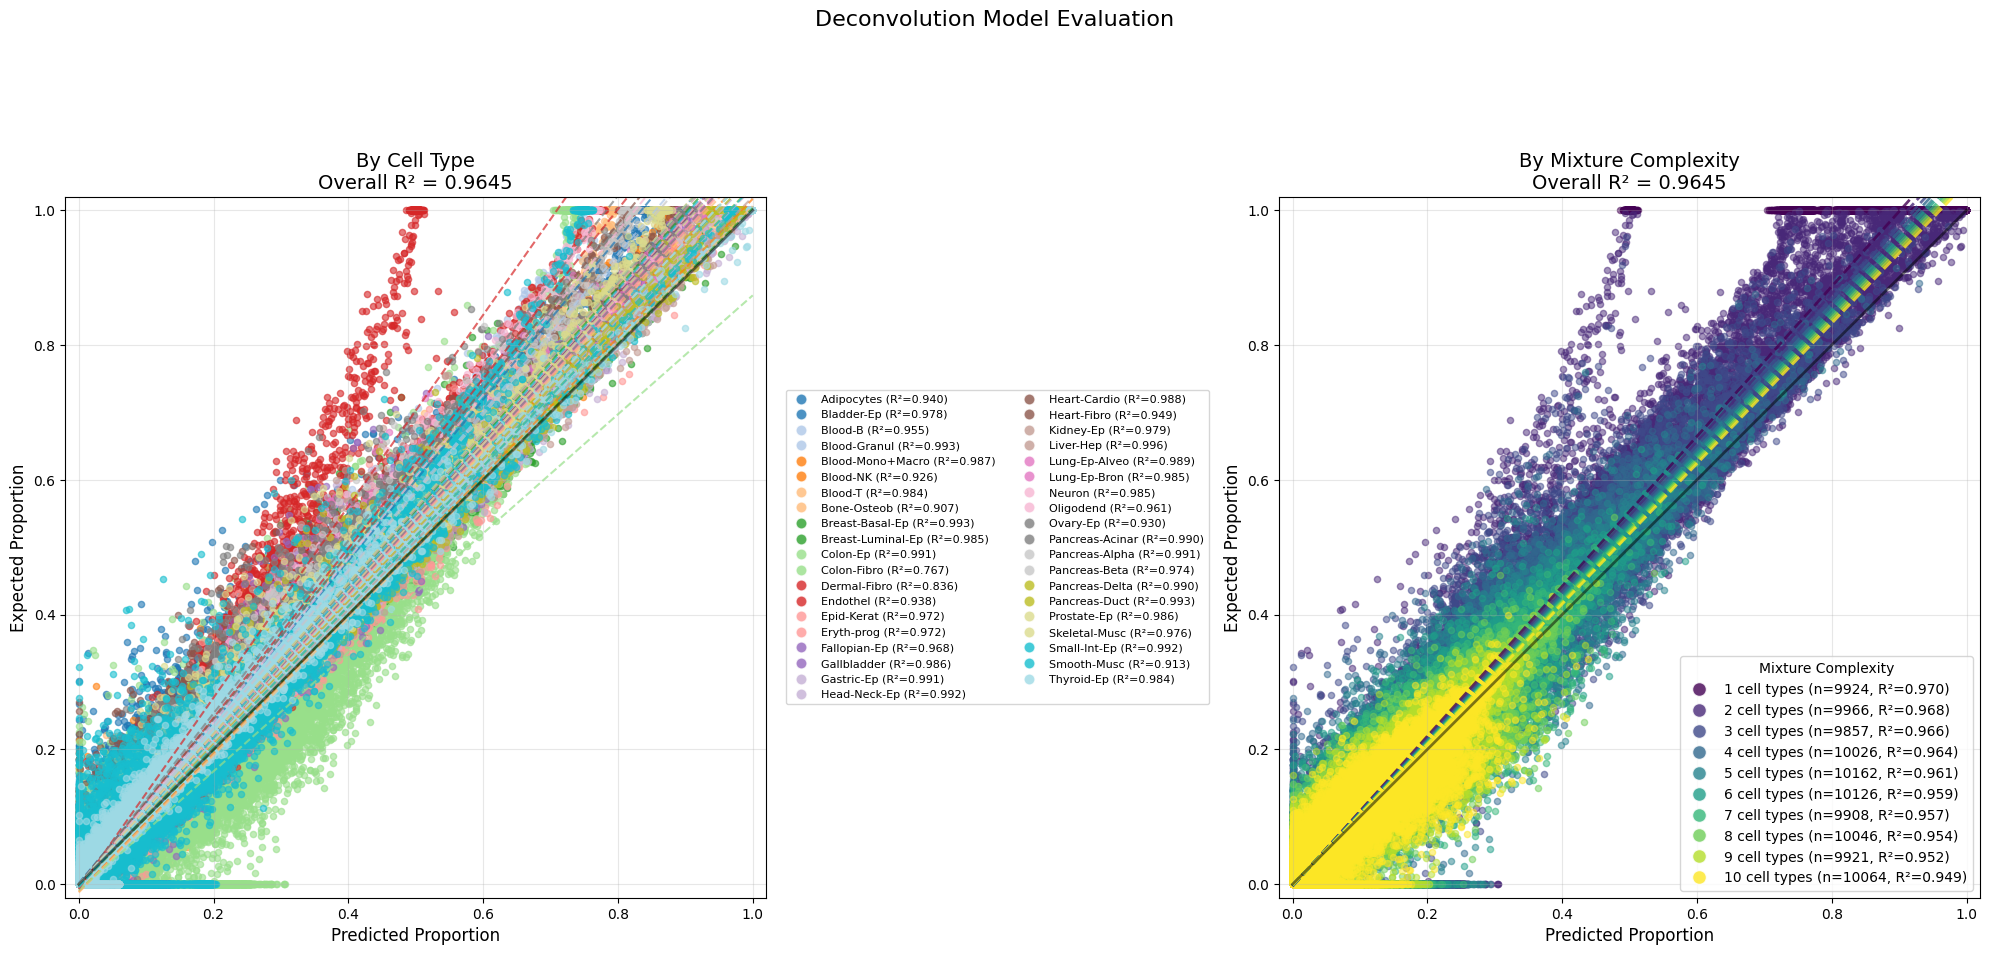

In [48]:
plot_deconvolution_results(target_proportions, uxm_results, labels_dict=labels_dict)